In [1]:
import numpy as np
import pandas as pd
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import math
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
path_MT = "/content/drive/MyDrive/Colab Notebooks/APM466/Bond_Data_MT_long.xlsx"
data_MT = pd.read_excel(path_MT)
data_MT.head()

,ISIN,Name,Coupon,Issue_Date,Maturity_Date,Obs_Date,Clean_Price
0,CA135087T792,CAN 2.75 Mar 31,0.0275,10/2/2025,3/1/2031,2026-01-05,98.813
1,CA135087T792,CAN 2.75 Mar 31,0.0275,10/2/2025,3/1/2031,2026-01-06,98.723
2,CA135087T792,CAN 2.75 Mar 31,0.0275,10/2/2025,3/1/2031,2026-01-07,98.888
3,CA135087T792,CAN 2.75 Mar 31,0.0275,10/2/2025,3/1/2031,2026-01-08,109.580
4,CA135087T792,CAN 2.75 Mar 31,0.0275,10/2/2025,3/1/2031,2026-01-09,98.913


In [3]:
path_ST = "/content/drive/MyDrive/Colab Notebooks/APM466/Bond_Data_ST_long.xlsx"
data_ST = pd.read_excel(path_ST)
data_ST.head()

,ISIN,Name,Coupon,Issue_Date,Maturity_Date,Obs_Date,Clean_Price
0,CA135087R226,CAN 4.5 Feb 26,0.045,11/1/2023,2/1/2026,2026-01-05,100.14
1,CA135087R226,CAN 4.5 Feb 26,0.045,11/1/2023,2/1/2026,2026-01-06,100.13
2,CA135087R226,CAN 4.5 Feb 26,0.045,11/1/2023,2/1/2026,2026-01-07,100.13
3,CA135087R226,CAN 4.5 Feb 26,0.045,11/1/2023,2/1/2026,2026-01-08,100.12
4,CA135087R226,CAN 4.5 Feb 26,0.045,11/1/2023,2/1/2026,2026-01-09,100.11


In [4]:
FACE = 100.0
FREQ = 2

def normalize_coupon(c):
    c = float(c)
    if c > 1 and c <= 100:
        return c / 100.0
    return c

def last_next_coupon_dates(settle, maturity):
    # move backward from maturity in 6-month steps until we bracket settlement
    step_months = 12 // FREQ  # 6
    next_cpn = maturity
    prev_cpn = maturity - relativedelta(months=step_months)

    if settle >= maturity:
        return (pd.NaT, pd.NaT)

    while prev_cpn > settle:
        next_cpn = prev_cpn
        prev_cpn = prev_cpn - relativedelta(months=step_months)

    return prev_cpn, next_cpn

def accrued_interest(settle, maturity, coupon):
    coupon = normalize_coupon(coupon)
    prev_cpn, next_cpn = last_next_coupon_dates(settle, maturity)

    if pd.isna(prev_cpn) or pd.isna(next_cpn):
        return np.nan

    C = FACE * coupon / FREQ  # coupon per half-year
    days_since = (settle - prev_cpn).days
    days_period = (next_cpn - prev_cpn).days
    return C * (days_since / days_period)

In [5]:
data_ST["Obs_Date"] = pd.to_datetime(data_ST["Obs_Date"])
data_ST["Maturity_Date"] = pd.to_datetime(data_ST["Maturity_Date"])

data_ST["AI"] = data_ST.apply(
    lambda r: accrued_interest(r["Obs_Date"], r["Maturity_Date"], r["Coupon"]),
    axis=1
)

data_ST["Dirty_Price"] = data_ST["Clean_Price"] + data_ST["AI"]

data_ST[["ISIN","Name","Obs_Date","Maturity_Date","Coupon","Clean_Price","AI","Dirty_Price"]].head()

,ISIN,Name,Obs_Date,Maturity_Date,Coupon,Clean_Price,AI,Dirty_Price
0,CA135087R226,CAN 4.5 Feb 26,2026-01-05,2026-02-01,0.045,100.14,1.919837,102.059837
1,CA135087R226,CAN 4.5 Feb 26,2026-01-06,2026-02-01,0.045,100.13,1.932065,102.062065
2,CA135087R226,CAN 4.5 Feb 26,2026-01-07,2026-02-01,0.045,100.13,1.944293,102.074293
3,CA135087R226,CAN 4.5 Feb 26,2026-01-08,2026-02-01,0.045,100.12,1.956522,102.076522
4,CA135087R226,CAN 4.5 Feb 26,2026-01-09,2026-02-01,0.045,100.11,1.968750,102.078750


In [6]:
data_MT["Obs_Date"] = pd.to_datetime(data_MT["Obs_Date"])
data_MT["Maturity_Date"] = pd.to_datetime(data_MT["Maturity_Date"])

data_MT["AI"] = data_MT.apply(
    lambda r: accrued_interest(r["Obs_Date"], r["Maturity_Date"], r["Coupon"]),
    axis=1
)

data_MT["Dirty_Price"] = data_MT["Clean_Price"] + data_MT["AI"]

data_MT[["ISIN","Name","Obs_Date","Maturity_Date","Coupon","Clean_Price","AI","Dirty_Price"]].head()

,ISIN,Name,Obs_Date,Maturity_Date,Coupon,Clean_Price,AI,Dirty_Price
0,CA135087T792,CAN 2.75 Mar 31,2026-01-05,2031-03-01,0.0275,98.813,0.957182,99.770182
1,CA135087T792,CAN 2.75 Mar 31,2026-01-06,2031-03-01,0.0275,98.723,0.964779,99.687779
2,CA135087T792,CAN 2.75 Mar 31,2026-01-07,2031-03-01,0.0275,98.888,0.972376,99.860376
3,CA135087T792,CAN 2.75 Mar 31,2026-01-08,2031-03-01,0.0275,109.580,0.979972,110.559972
4,CA135087T792,CAN 2.75 Mar 31,2026-01-09,2031-03-01,0.0275,98.913,0.987569,99.900569


In [7]:
def yearfrac_act365(d1, d2):
    d1 = pd.to_datetime(d1).normalize()
    d2 = pd.to_datetime(d2).normalize()
    return (d2 - d1).days / 365.0

def last_next_coupon_dates(settle, maturity, freq=2):
    step_months = 12 // freq
    next_cpn = maturity
    prev_cpn = maturity - relativedelta(months=step_months)

    if settle >= maturity:
        return (pd.NaT, pd.NaT)

    while prev_cpn > settle:
        next_cpn = prev_cpn
        prev_cpn = prev_cpn - relativedelta(months=step_months)

    return prev_cpn, next_cpn

def cashflows_after_settle(settle, maturity, coupon, face=100.0, freq=2):
    """
    Remaining cashflows (date, amount) from next coupon date to maturity.
    """
    coupon = normalize_coupon(coupon)
    prev_cpn, next_cpn = last_next_coupon_dates(settle, maturity, freq=freq)
    if pd.isna(next_cpn):
        return []

    C = face * coupon / freq
    step_months = 12 // freq

    dates = []
    d = next_cpn
    while d < maturity:
        dates.append(d)
        d = d + relativedelta(months=step_months)
    dates.append(maturity)

    cfs = []
    for d in dates:
        if d < maturity:
            cfs.append((d, C))
        else:
            cfs.append((d, C + face))
    return cfs

def price_from_ytm(settle, maturity, coupon, y, face=100.0, freq=2):
    """
    Dirty price implied by annual YTM y with semi-annual compounding.
    """
    cfs = cashflows_after_settle(settle, maturity, coupon, face=face, freq=freq)
    if not cfs:
        return np.nan

    pv = 0.0
    for d, cf in cfs:
        t = yearfrac_act365(settle, d)
        pv += cf / (1.0 + y / freq) ** (freq * t)
    return pv

def solve_ytm_bisection(settle, maturity, coupon, dirty, face=100.0, freq=2, tol=1e-10):
    """
    Solve y such that price_from_ytm(...) = dirty using bisection.
    Returns annual y as decimal (0.05 = 5%).
    """
    if dirty <= 0:
        return np.nan

    low, high = 0.0, 1.0  # 0% to 100%
    p_low = price_from_ytm(settle, maturity, coupon, low, face=face, freq=freq)
    p_high = price_from_ytm(settle, maturity, coupon, high, face=face, freq=freq)

    # Expand high until model price is below market dirty price
    tries = 0
    while not np.isnan(p_high) and p_high > dirty and high < 10.0:
        high *= 2.0
        p_high = price_from_ytm(settle, maturity, coupon, high, face=face, freq=freq)
        tries += 1
        if tries > 50:
            return np.nan

    if np.isnan(p_low) or np.isnan(p_high) or not (p_low >= dirty >= p_high):
        return np.nan

    for _ in range(200):
        mid = 0.5 * (low + high)
        p_mid = price_from_ytm(settle, maturity, coupon, mid, face=face, freq=freq)
        if np.isnan(p_mid):
            return np.nan
        if abs(p_mid - dirty) < tol:
            return mid
        if p_mid > dirty:
            low = mid
        else:
            high = mid

    return 0.5 * (low + high)

def add_ytm(df):
    """
    df must have: Obs_Date, Maturity_Date, Coupon, Dirty_Price
    Adds a YTM column.
    """
    out = df.copy()
    out["Obs_Date"] = pd.to_datetime(out["Obs_Date"])
    out["Maturity_Date"] = pd.to_datetime(out["Maturity_Date"])

    out["YTM"] = out.apply(
        lambda r: solve_ytm_bisection(
            r["Obs_Date"],
            r["Maturity_Date"],
            r["Coupon"],
            float(r["Dirty_Price"]),
            face=FACE,
            freq=FREQ
        ),
        axis=1
    )
    return out

In [8]:
data_MT = add_ytm(data_MT)
data_ST = add_ytm(data_ST)

data_MT.head()
data_ST.head()


,ISIN,Name,Coupon,Issue_Date,Maturity_Date,Obs_Date,Clean_Price,AI,Dirty_Price,YTM
0,CA135087R226,CAN 4.5 Feb 26,0.045,11/1/2023,2026-02-01,2026-01-05,100.14,1.919837,102.059837,0.025324
1,CA135087R226,CAN 4.5 Feb 26,0.045,11/1/2023,2026-02-01,2026-01-06,100.13,1.932065,102.062065,0.025994
2,CA135087R226,CAN 4.5 Feb 26,0.045,11/1/2023,2026-02-01,2026-01-07,100.13,1.944293,102.074293,0.025269
3,CA135087R226,CAN 4.5 Feb 26,0.045,11/1/2023,2026-02-01,2026-01-08,100.12,1.956522,102.076522,0.025992
4,CA135087R226,CAN 4.5 Feb 26,0.045,11/1/2023,2026-02-01,2026-01-09,100.11,1.968750,102.078750,0.026779


In [9]:
selected_isins = [
    "CA135087L518","CA135087L930",
    "CA135087M847","CA135087N837",
    "CA135087P576","CA135087Q491",
    "CA135087Q988","CA135087R895",
    "CA135087S471","CA135087T388"
]

In [10]:
selected_bonds = pd.concat([data_ST, data_MT], ignore_index=True).copy()

# basic cleanup
selected_bonds["Obs_Date"] = pd.to_datetime(selected_bonds["Obs_Date"])
selected_bonds["Maturity_Date"] = pd.to_datetime(selected_bonds["Maturity_Date"])

# keep only selected bonds + valid YTM
selected_bonds = selected_bonds[selected_bonds["ISIN"].isin(selected_isins)].copy()
selected_bonds = selected_bonds.dropna(subset=["YTM"])

selected_bonds["TTM"] = (selected_bonds["Maturity_Date"] - selected_bonds["Obs_Date"]).dt.days / 365.0

# keep within 0-5 years (as requested)
selected_bonds = selected_bonds[(selected_bonds["TTM"] > 0) & (selected_bonds["TTM"] <= 5)].copy()

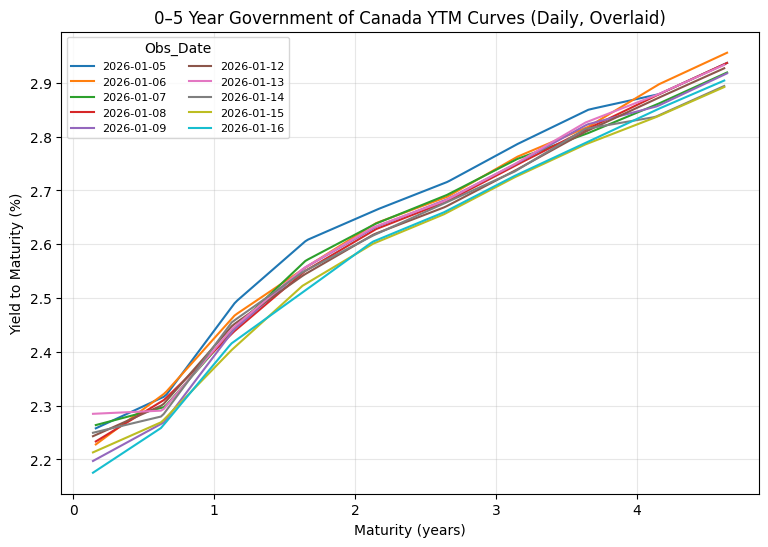

In [11]:
grid = np.linspace(0, 5, 250)

plt.figure(figsize=(9, 6))

for d, g in selected_bonds.groupby("Obs_Date"):
    g = g.sort_values("TTM")
    x = g["TTM"].to_numpy()
    y = g["YTM"].to_numpy() * 100  # convert to %

    if len(np.unique(x)) != len(x):
        tmp = pd.DataFrame({"TTM": x, "YTM": y}).groupby("TTM", as_index=False).mean()
        x = tmp["TTM"].to_numpy()
        y = tmp["YTM"].to_numpy()

    if len(x) < 2:
        continue

    y_grid = np.interp(grid, x, y)
    y_grid[(grid < x.min()) | (grid > x.max())] = np.nan

    plt.plot(grid, y_grid, label=str(d.date()))

plt.xlabel("Maturity (years)")
plt.ylabel("Yield to Maturity (%)")
plt.title("0–5 Year Government of Canada YTM Curves (Daily, Overlaid)")
plt.grid(True, alpha=0.3)
plt.legend(title="Obs_Date", fontsize=8, ncol=2)
plt.show()


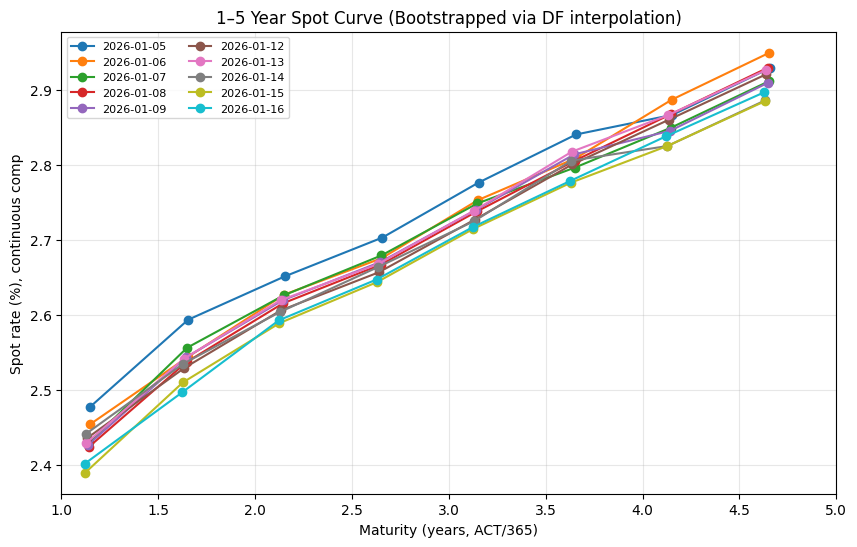

In [13]:
def coupon_schedule(obs_date, maturity_date):
    """
    Build remaining coupon payment dates by stepping back 6 months from maturity.
    Keeps dates strictly after obs_date.
    """
    obs_date = pd.to_datetime(obs_date).normalize()
    maturity_date = pd.to_datetime(maturity_date).normalize()

    dates = [maturity_date]
    d = maturity_date
    # step back by 6 months until we go past obs_date
    while True:
        d = d - pd.DateOffset(months=6)
        if d <= obs_date:
            break
        dates.append(d)

    dates = sorted(dates)
    return dates  # includes maturity

def df_loglinear(t, T_nodes, lnDF_nodes):
    """
    Log-linear interpolation of discount factors: ln DF is linear in time.
    Assumes T_nodes sorted ascending, includes 0 with lnDF=0.
    """
    if t <= 0:
        return 1.0

    T_nodes = np.asarray(T_nodes, dtype=float)
    lnDF_nodes = np.asarray(lnDF_nodes, dtype=float)

    if len(T_nodes) == 1:
        # only DF(0)=1 known; can't interpolate -> return None
        return None

    if t <= T_nodes[0]:
        return float(np.exp(lnDF_nodes[0]))

    if t >= T_nodes[-1]:
        # flat-forward extrapolation in lnDF slope
        slope = (lnDF_nodes[-1] - lnDF_nodes[-2]) / (T_nodes[-1] - T_nodes[-2])
        lnDF = lnDF_nodes[-1] + slope * (t - T_nodes[-1])
        return float(np.exp(lnDF))

    lnDF = np.interp(t, T_nodes, lnDF_nodes)
    return float(np.exp(lnDF))

def ytm_to_cc(ytm_sa, t):
    """
    Convert nominal semiannual-compounded yield to continuous-comp spot proxy at time t:
      DF(t) = (1 + y/2)^(-2t) = exp(-r_cc * t)
      r_cc = (2 * ln(1 + y/2))
    """
    return 2.0 * np.log(1.0 + ytm_sa / 2.0)

def bootstrap_one_day(g_day):
    """
    Bootstrap discount factors and spot rates for one Obs_Date slice.
    Requires columns:
      Coupon (decimal), Dirty_Price, Obs_Date, Maturity_Date, (optional) YTM, TTM.
    Returns DataFrame with T, Spot_CC, Spot_SA, DF, plus identifiers.
    """
    # one row per bond
    g = g_day.drop_duplicates(subset=["ISIN"]).copy()

    # sort by actual maturity time (use TTM)
    g = g.sort_values("TTM").reset_index(drop=True)

    # curve storage
    T_nodes = [0.0]
    lnDF_nodes = [0.0]  # ln DF(0)=0

    out = []

    for _, r in g.iterrows():
        obs = pd.to_datetime(r["Obs_Date"]).normalize()
        mat = pd.to_datetime(r["Maturity_Date"]).normalize()

        P = float(r["Dirty_Price"])
        c = float(r["Coupon"])
        if P <= 0 or c < 0:
            continue

        # cashflow dates and times
        pay_dates = coupon_schedule(obs, mat)
        times = [yearfrac_act365(obs, d) for d in pay_dates]
        if len(times) == 0:
            continue

        T = times[-1]
        if T <= 0:
            continue

        C = FACE * c / FREQ

        # PV of all coupons before maturity using interpolated DF
        pv_known = 0.0
        ok = True

        for t in times[:-1]:
            DF_t = df_loglinear(t, T_nodes, lnDF_nodes)
            if DF_t is None:
                if "YTM" in r and pd.notna(r["YTM"]):
                    y = float(r["YTM"])
                    rcc = ytm_to_cc(y, t)
                    DF_t = float(np.exp(-rcc * t))
                else:
                    ok = False
                    break
            pv_known += C * DF_t

        if not ok:
            continue

        # solve DF at maturity
        DF_T = (P - pv_known) / (FACE + C)
        if DF_T <= 0:
            continue

        # append to curve nodes
        T_nodes.append(T)
        lnDF_nodes.append(float(np.log(DF_T)))

        # spot rates at T
        spot_cc = -np.log(DF_T) / T
        spot_sa = FREQ * (DF_T ** (-1.0 / (FREQ * T)) - 1.0)

        out.append({
            "ISIN": r["ISIN"],
            "Name": r.get("Name", ""),
            "T": T,
            "DF": DF_T,
            "Spot_CC": spot_cc,
            "Spot_SA": spot_sa,
            "Obs_Date": obs,
            "Maturity_Date": mat
        })

    if not out:
        return None

    return pd.DataFrame(out).sort_values("T").reset_index(drop=True)

df2 = selected_bonds.copy()
df2["Obs_Date"] = pd.to_datetime(df2["Obs_Date"])
df2["Maturity_Date"] = pd.to_datetime(df2["Maturity_Date"])
df2["Coupon"] = df2["Coupon"].astype(float)
df2["Dirty_Price"] = df2["Dirty_Price"].astype(float)
df2["TTM"] = df2["TTM"].astype(float)
if "YTM" in df2.columns:
    df2["YTM"] = df2["YTM"].astype(float)

# keep 0–5y for bootstrapping stability; plot 1–5y
df2 = df2[(df2["TTM"] > 0) & (df2["TTM"] <= 5.0)].copy()

spot_curves = {}
for day in sorted(df2["Obs_Date"].unique()):
    g_day = df2[df2["Obs_Date"] == day].copy()
    s = bootstrap_one_day(g_day)
    if s is not None and len(s) >= 2:
        spot_curves[day] = s

# -------------------------
# PLOT 1–5 YEAR CURVE ONLY
# -------------------------
plt.figure(figsize=(10, 6))
for day, s in spot_curves.items():
    s15 = s[(s["T"] >= 1.0) & (s["T"] <= 5.0)]
    if len(s15) == 0:
        continue
    plt.plot(s15["T"], 100*s15["Spot_CC"], marker="o", linewidth=1.5,
             label=str(pd.to_datetime(day).date()))

plt.xlim(1, 5)
plt.xlabel("Maturity (years, ACT/365)")
plt.ylabel("Spot rate (%), continuous comp")
plt.title("1–5 Year Spot Curve (Bootstrapped via DF interpolation)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.show()

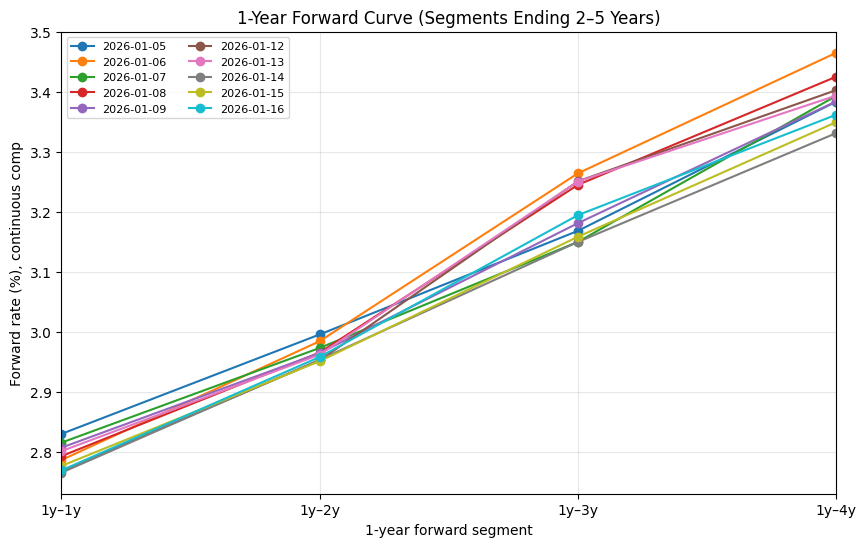

In [14]:
def build_lnDF_nodes(s):
    """
    From a bootstrapped curve table s (with columns T and DF or Spot_CC),
    return sorted (T_nodes, lnDF_nodes) including (0, lnDF=0).
    """
    s = s.dropna(subset=["T"]).copy()
    s = s[s["T"] > 0].sort_values("T")

    if "DF" in s.columns:
        DF = s["DF"].astype(float).values
    else:
        # reconstruct DF from continuous spot if DF not stored
        # DF(T) = exp(-Spot_CC(T) * T)
        DF = np.exp(-s["Spot_CC"].astype(float).values * s["T"].astype(float).values)

    T_nodes = np.concatenate([[0.0], s["T"].astype(float).values])
    lnDF_nodes = np.concatenate([[0.0], np.log(DF)])

    # ensure strictly increasing T (drop duplicates if any)
    keep = np.ones_like(T_nodes, dtype=bool)
    keep[1:] = np.diff(T_nodes) > 1e-10
    T_nodes = T_nodes[keep]
    lnDF_nodes = lnDF_nodes[keep]
    return T_nodes, lnDF_nodes

def one_year_forward_curve_from_spot(s, starts=(1,2,3,4), comp="cc"):
    """
    Compute 1Y forward rates f(T, T+1) for T in starts.
    comp="cc" uses continuous-comp forward: ln(DF(T)/DF(T+1)).
    Returns DataFrame with columns: Start, End, Fwd_CC.
    """
    T_nodes, lnDF_nodes = build_lnDF_nodes(s)

    out = []
    for T in starts:
        DF_T  = df_loglinear(T,   T_nodes, lnDF_nodes)
        DF_T1 = df_loglinear(T+1, T_nodes, lnDF_nodes)

        if DF_T <= 0 or DF_T1 <= 0:
            continue

        # continuous-compounded 1-year forward (annualized since delta=1)
        f_cc = np.log(DF_T / DF_T1)

        out.append((T, T+1, f_cc))

    return pd.DataFrame(out, columns=["Start", "End", "Fwd_CC"])

# -----------------------------
# Build forward curves per day
# -----------------------------
forward_curves = {}

for day, s in spot_curves.items():
    f = one_year_forward_curve_from_spot(s, starts=(1,2,3,4))
    if len(f) == 4:   # should have 1->2,2->3,3->4,4->5
        forward_curves[day] = f

# -------------
# Plot (1–4 on x)
# -------------
plt.figure(figsize=(10, 6))
for day, f in forward_curves.items():
    plt.plot(f["Start"], 100*f["Fwd_CC"], marker="o", linewidth=1.5,
             label=str(pd.to_datetime(day).date()))

plt.xlim(1, 4)
plt.xticks([1,2,3,4], ["1y–1y","1y–2y","1y–3y","1y–4y"])
plt.xlabel("1-year forward segment")
plt.ylabel("Forward rate (%), continuous comp")
plt.title("1-Year Forward Curve (Segments Ending 2–5 Years)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.show()

In [15]:
TARGET_YEARS = np.array([1, 2, 3, 4, 5], dtype=float)

def build_yields_df(df):
    d = df.copy()
    d["Obs_Date"] = pd.to_datetime(d["Obs_Date"])
    d["TTM"] = d["TTM"].astype(float)
    d["YTM"] = d["YTM"].astype(float)

    # keep 0–5 for stability; we will extract 1–5 nodes
    d = d[(d["TTM"] > 0) & (d["TTM"] <= 5)].copy()

    rows = []
    idx = []

    for day in sorted(d["Obs_Date"].unique()):
        g = d[d["Obs_Date"] == day].drop_duplicates(subset=["ISIN"]).copy()
        g = g.sort_values("TTM")

        x = g["TTM"].to_numpy(dtype=float)
        y = g["YTM"].to_numpy(dtype=float)

        # need at least two bonds to interpolate
        if len(x) < 2:
            continue

        # interpolation in yield space (simple and acceptable for this step)
        y_nodes = np.interp(TARGET_YEARS, x, y)

        rows.append(y_nodes)
        idx.append(pd.to_datetime(day))

    yields_df = pd.DataFrame(rows, index=idx, columns=["1Y", "2Y", "3Y", "4Y", "5Y"]).sort_index()
    return yields_df

yields_df=build_yields_df(selected_bonds)
yields_df.head()

,1Y,2Y,3Y,4Y,5Y
2026-01-05,0.024394,0.026469,0.027648,0.028700,0.029394
2026-01-06,0.024251,0.026147,0.027401,0.028731,0.029581
2026-01-07,0.024013,0.026180,0.027385,0.028446,0.029209
2026-01-08,0.024016,0.026053,0.027276,0.028592,0.029385
2026-01-09,0.023925,0.026101,0.027306,0.028468,0.029188


In [16]:
def log_returns(df_rates):
    X = np.log(df_rates.shift(-1) / df_rates)
    return X.iloc[:-1]

X_yield = log_returns(yields_df)     # shape ~9×5
cov_yield = X_yield.cov(ddof=1)
cov_yield

,1Y,2Y,3Y,4Y,5Y
1Y,0.000055,0.000004,0.000003,0.000014,0.000011
2Y,0.000004,0.000028,0.000021,-0.000002,-0.000013
3Y,0.000003,0.000021,0.000017,0.000001,-0.000006
4Y,0.000014,-0.000002,0.000001,0.000037,0.000045
5Y,0.000011,-0.000013,-0.000006,0.000045,0.000061


In [17]:
def pack_fwds_df(forward_curves):
    rows = []
    idx = []

    for day in sorted(forward_curves.keys()):
        f = forward_curves[day].sort_values("Start")
        f = f[f["Start"].isin([1,2,3,4])]

        if len(f) != 4:
            continue

        rows.append(f["Fwd_CC"].to_numpy(dtype=float))
        idx.append(pd.to_datetime(day))

    fwds_df = pd.DataFrame(
        rows,
        index=idx,
        columns=["1y1y", "1y2y", "1y3y", "1y4y"]
    ).sort_index()

    return fwds_df

fwds_df = pack_fwds_df(forward_curves)
fwds_df

,1y1y,1y2y,1y3y,1y4y
2026-01-05,0.028302,0.029961,0.031689,0.033844
2026-01-06,0.027866,0.029848,0.032648,0.034658
2026-01-07,0.028157,0.029736,0.031505,0.033940
2026-01-08,0.027931,0.029658,0.032456,0.034259
2026-01-09,0.028073,0.029651,0.031817,0.033848
2026-01-12,0.027682,0.029529,0.032515,0.034035
2026-01-13,0.028015,0.029625,0.032511,0.033944
2026-01-14,0.027656,0.029541,0.031504,0.033319
2026-01-15,0.027768,0.029515,0.031590,0.033501
2026-01-16,0.027694,0.029585,0.031951,0.033625


In [18]:
X_fwd = log_returns(fwds_df)

cov_fwd = X_fwd.cov(ddof=1)
cov_fwd

,1y1y,1y2y,1y3y,1y4y
1y1y,0.000114,0.000017,-0.000134,-0.000074
1y2y,0.000017,0.000007,-0.000002,-0.000002
1y3y,-0.000134,-0.000002,0.000628,0.000343
1y4y,-0.000074,-0.000002,0.000343,0.000208


In [19]:
def eig_sorted(cov: pd.DataFrame):
    A = cov.to_numpy(dtype=float)
    vals, vecs = np.linalg.eigh(A)          # ascending order
    idx = np.argsort(vals)[::-1]            # descending
    vals = vals[idx]
    vecs = vecs[:, idx]                     # columns are eigenvectors
    return vals, vecs

# yields
eval_y, evec_y = eig_sorted(cov_yield)
# forwards
eval_f, evec_f = eig_sorted(cov_fwd)

# Put into labeled tables
eigvals_y = pd.Series(eval_y, name="eigenvalue")
eigvecs_y = pd.DataFrame(evec_y, index=cov_yield.index,
                         columns=[f"PC{k+1}" for k in range(len(eval_y))])

eigvals_f = pd.Series(eval_f, name="eigenvalue")
eigvecs_f = pd.DataFrame(evec_f, index=cov_fwd.index,
                         columns=[f"PC{k+1}" for k in range(len(eval_f))])

eigvals_y, eigvecs_y, eigvals_f, eigvecs_f

(0    1.033498e-04
 1    5.639675e-05
 2    3.760027e-05
 3    3.082759e-07
 4    1.207623e-07
 Name: eigenvalue, dtype: float64,
          PC1       PC2       PC3       PC4       PC5
 1Y -0.314612 -0.778456  0.540449  0.040313 -0.036268
 2Y  0.136963 -0.474968 -0.596816 -0.475917 -0.415885
 3Y  0.065933 -0.344966 -0.495736  0.745570  0.273902
 4Y -0.574251 -0.012533 -0.278898 -0.385222  0.666257
 5Y -0.740371  0.221931 -0.167890  0.260013 -0.553899,
 0    0.000852
 1    0.000086
 2    0.000016
 3    0.000004
 Name: eigenvalue, dtype: float64,
            PC1       PC2       PC3       PC4
 1y1y -0.203253 -0.959740  0.011351  0.193542
 1y2y -0.007023 -0.196554 -0.071300 -0.977872
 1y3y  0.854478 -0.173760 -0.485342  0.064177
 1y4y  0.478024 -0.100366  0.871338 -0.046792)